In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('albert-einstein_gray.jpg',cv2.IMREAD_GRAYSCALE)
num_rows, num_cols = img.shape[:2]

# Smoothing Filter (Blurring)

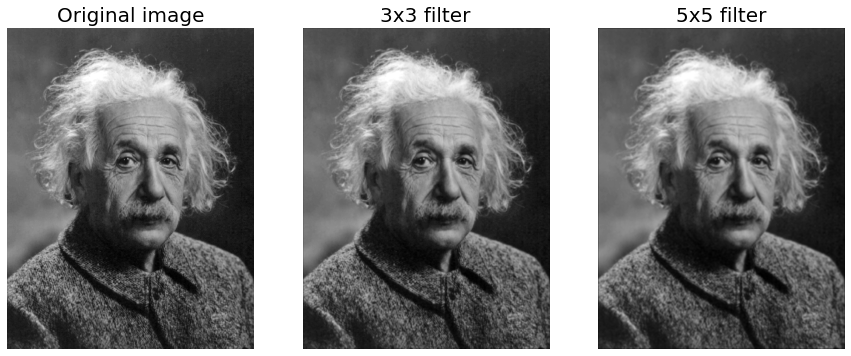

In [26]:

kernel_3x3 = np.ones((3,3), np.float32) / 9.0
#This is equivilent to np.array([[1,1,1],[1,1,1],[1,1,1]]) / 9
kernel_5x5 = np.ones((5,5), np.float32) / 25.0
kernel_5x5 = np.ones((5,5), np.float32) / 25.0

output3 = cv2.filter2D(img, -1, kernel_3x3, borderType=cv2.BORDER_CONSTANT) #the second parameter is the desirable depth of destination image. Value -1 represents that the resulting image will have same depth as the source image.
output5= cv2.filter2D(img, -1, kernel_5x5, borderType=cv2.BORDER_CONSTANT)

#use cv2.copyMakeBorder if you'd like to pad the images using a custom method.


plt.figure(figsize=(15,15))
plt.subplot(231), plt.imshow(img,cmap='gray'), plt.axis('off'), plt.title('Original image', size=20)
plt.subplot(232), plt.imshow(output3,cmap='gray'), plt.axis('off'), plt.title('3x3 filter', size=20)
plt.subplot(233), plt.imshow(output5,cmap='gray'), plt.axis('off'), plt.title('5x5 filter', size=20) 

plt.show()



# Exercise
* Apply three more bluring filters with the kernal sizes of 9, 15, and 35. Compare the results.
* Observe the border effect and change the borderType. Use OpenCV documentation to discover different borderTypes.
*(optional) use cv2.copyMakeBorder to pad the image using your own padding method.
* Apply a weigthed bluring filter to your image

# Median filter for grainy images

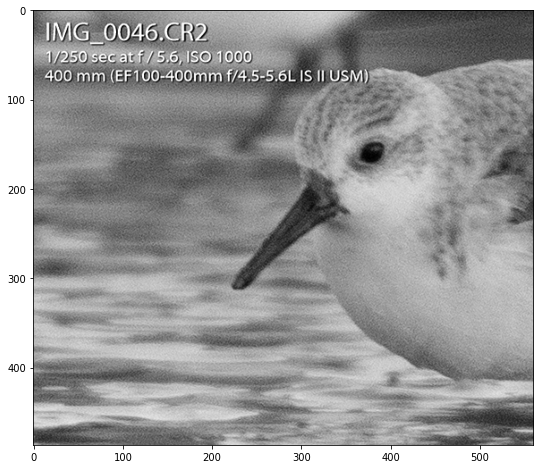

In [27]:
grainy = cv2.imread(r'grainy.png')
grainy = cv2.cvtColor(grainy,cv2.COLOR_BGR2GRAY)
plt.figure(figsize = (10,8)) 
plt.imshow(grainy,cmap='gray')

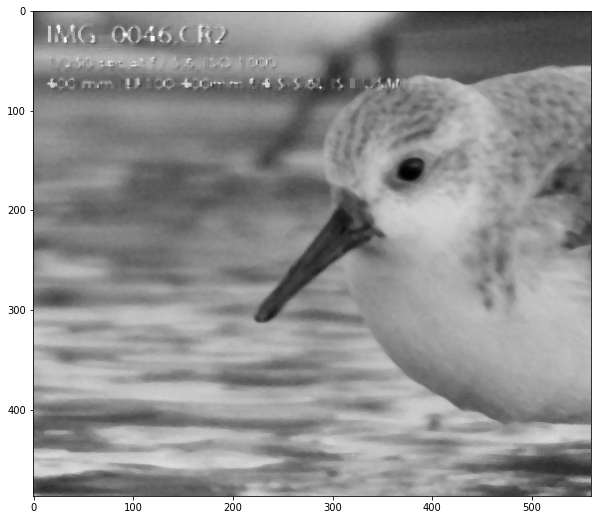

In [31]:
median = cv2.medianBlur(grainy,5)
plt.figure(figsize = (10,10)) 
plt.imshow(median,cmap='gray')

# Exercise
* Investigate and try different the kernel sizes of the filter. Explain their impact to the image.

# Sharpening Filter

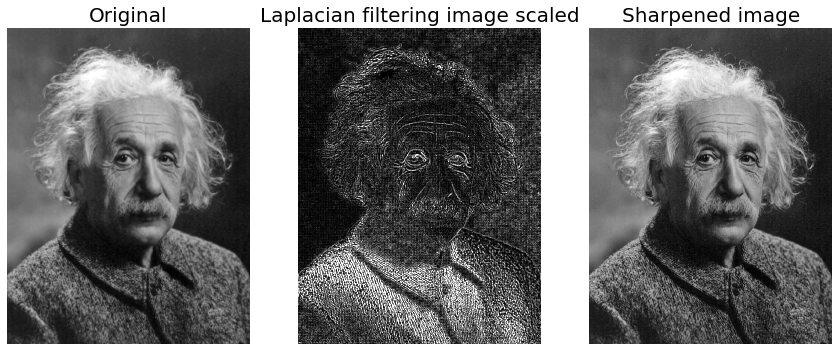

In [6]:
kernel_laplacian = np.array([[0,1,0], [1,-4,1], [0,1,0]])
kernel_sharpen = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])

laplacian = cv2.filter2D(img, -1, kernel_laplacian)
sharpen = cv2.filter2D(img, -1, kernel_sharpen)

#use cv2.copyMakeBorder if you'd like to pad the images using a custom method.


plt.figure(figsize=(20,15))
plt.subplot(141), plt.imshow(img,cmap='gray'), plt.axis('off'), plt.title('Original', size=20)
plt.subplot(142), plt.imshow(laplacian,cmap='gray', vmin=0, vmax=20), plt.axis('off'), plt.title('Laplacian filtering image scaled', size=20)
plt.subplot(143), plt.imshow(sharpen,cmap='gray'), plt.axis('off'), plt.title('Sharpened image', size=20)
#plt.subplot(144), plt.imshow(sharpen3,cmap='gray'), plt.axis('off'), plt.title('Enhancing edges', size=20) 

plt.show()

## x-derivative picks up vertical patterns and y-derivative picks up horizontal patterns. 

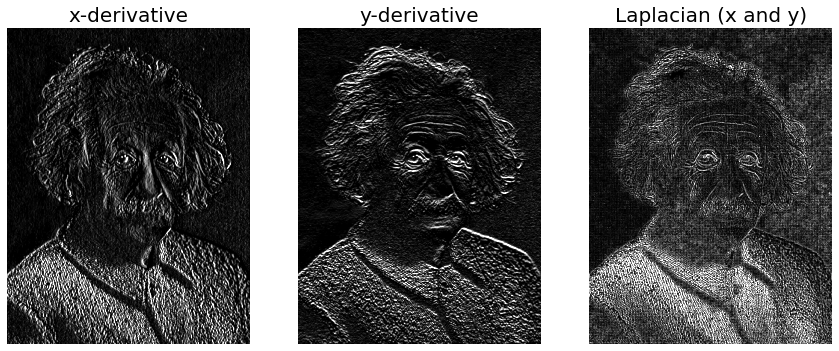

In [23]:

kernel_sobelx = np.array([[-1,0,1], [-2,0,2], [-1,0,1]])
kernel_sobely = np.array([[-1,-2,-1], [0,0,0], [1,2,1]])

sobelx = cv2.filter2D(img, -1, kernel_sobelx)
sobely = cv2.filter2D(img, -1, kernel_sobely)

plt.figure(figsize=(20,15))
plt.subplot(141), plt.imshow(sobelx,cmap='gray', vmin=0, vmax=120), plt.axis('off'), plt.title('x-derivative', size=20)
plt.subplot(142), plt.imshow(sobely,cmap='gray', vmin=0, vmax=120), plt.axis('off'), plt.title('y-derivative', size=20)
plt.subplot(143), plt.imshow(laplacian,cmap='gray', vmin=0, vmax=20), plt.axis('off'), plt.title('Laplacian (x and y)', size=20)
#plt.subplot(144), plt.imshow(sharpen3,cmap='gray'), plt.axis('off'), plt.title('Enhancing edges', size=20) 

plt.show()

# Laplacian filter can be used for object detection

(<matplotlib.axes._subplots.AxesSubplot at 0x7f95972e2d10>,
 (-0.5, 424.5, 281.5, -0.5),
 Text(0.5, 1.0, 'Laplacian filtering image scaled'))

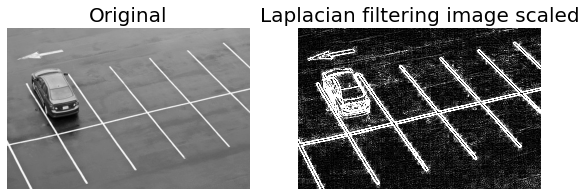

In [14]:
parking = cv2.imread(r'parking.jpg')
parking_rgb = cv2.cvtColor(parking,cv2.COLOR_BGR2RGB)
parking = cv2.cvtColor(parking,cv2.COLOR_BGR2GRAY)

kernel_laplacian = np.array([[0,1,0], [1,-4,1], [0,1,0]])
laplacian_parking = cv2.filter2D(parking, -1, kernel_laplacian)

plt.figure(figsize=(20,15))
plt.subplot(141), plt.imshow(parking,cmap='gray'), plt.axis('off'), plt.title('Original', size=20)
plt.subplot(142), plt.imshow(laplacian_parking,cmap='gray', vmin=0, vmax=20), plt.axis('off'), plt.title('Laplacian filtering image scaled', size=20)


# Different variants of sharpening filters.

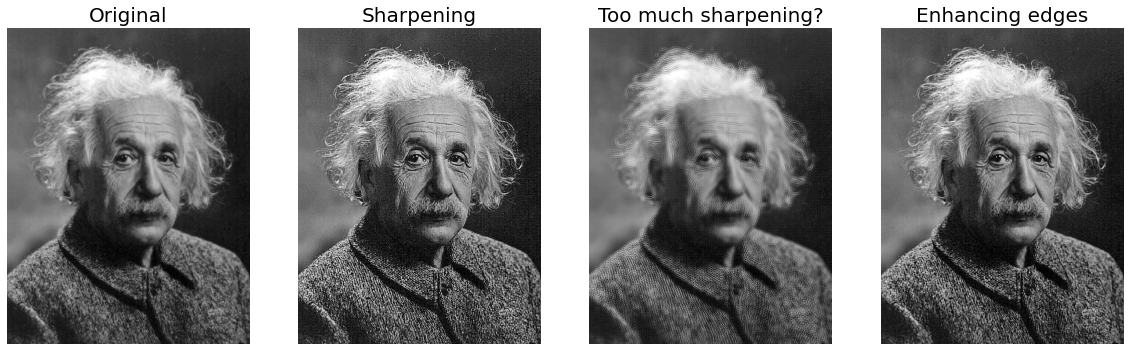

In [5]:
kernel_sharpen_1 = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
kernel_sharpen_2 = np.array([[1,1,1], [1,-7,1], [1,1,1]])
kernel_sharpen_3 = np.array([[-1,-1,-1,-1,-1],
                             [-1,2,2,2,-1],
                             [-1,2,8,2,-1],
                             [-1,2,2,2,-1],
                             [-1,-1,-1,-1,-1]]) / 8.0

sharpen1 = cv2.filter2D(img, -1, kernel_sharpen_1)
sharpen2 = cv2.filter2D(img, -1, kernel_sharpen_2)
sharpen3 = cv2.filter2D(img, -1, kernel_sharpen_3)

#use cv2.copyMakeBorder if you'd like to pad the images using a custom method.


plt.figure(figsize=(20,15))
plt.subplot(141), plt.imshow(img,cmap='gray'), plt.axis('off'), plt.title('Original', size=20)
plt.subplot(142), plt.imshow(sharpen1,cmap='gray'), plt.axis('off'), plt.title('Sharpening', size=20)
plt.subplot(143), plt.imshow(sharpen2,cmap='gray'), plt.axis('off'), plt.title('Too much sharpening?', size=20)
plt.subplot(144), plt.imshow(sharpen3,cmap='gray'), plt.axis('off'), plt.title('Enhancing edges', size=20) 

plt.show()

# Exercise
* Research Sobel filter and it's OpenCV implementations.
* Use a demo to showcase how Sobel filter can be used for a real-world application